# NFL Quarterback Hall of Fame Prediction Model
This notebook trains and tests several machine learning models to predict if an NFL QB is in the Hall of Fame based on career statistics.

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

## Load the Data

In [32]:
df = pd.read_csv('all_stats.csv')
print(f"Data shape: {df.shape}")
df.head()

print(df.columns.tolist())

Data shape: (196, 66)
['Player', 'PB', 'All-Pro', 'MVP', 'SB_Wins', 'Yds', 'From', 'To', 'Age_Start', 'Age_End', 'GS', 'Cmp', 'Att', 'Inc', 'Cmp%', 'Yds.1', 'TD', 'Int', 'Pick6', 'TD%', 'Int%', 'Rate', 'Sk', 'Yds.2', 'Sk%', 'Y/A', 'AY/A', 'ANY/A', 'Y/C', 'Y/G', 'Succ%', 'W', 'L', 'T', '4QC', 'GWD', 'MVP.1', 'SB_Wins.1', 'P_Yds', 'P_G', 'P_GS', 'P_Cmp', 'P_Att', 'P_Inc', 'P_Cmp%', 'P_Yds.1', 'P_TD', 'P_Int', 'P_Pick6', 'P_TD%', 'P_Int%', 'P_Rate', 'P_Sk', 'P_Yds.2', 'P_Sk%', 'P_Y/A', 'P_AY/A', 'P_ANY/A', 'P_Y/C', 'P_Y/G', 'P_Succ%', 'P_W', 'P_L', 'P_4QC', 'P_GWD', 'HOF']


## Impute Missing Values
We fill missing playoff statistics (`P_...`) with 0, as NaN indicates the player did not play in the playoffs. For other statistics (mostly rate stats missing for older players), we use median imputation.

In [33]:
# Fill playoff stats with 0
p_cols = [c for c in df.columns if c.startswith('P_')]
df[p_cols] = df[p_cols].fillna(0)

# Fill other numeric missing values (e.g. Succ%, Sk, etc.) with the column median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


## Train-Test Split

In [34]:
X = df.drop(columns=['Player', 'HOF'])
y = df['HOF']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=57, stratify=y)
print(f"Training instances: {len(X_train)}, Testing instances: {len(X_test)}")

Training instances: 156, Testing instances: 40


## Train & Evaluate Models

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        34
           1       0.75      1.00      0.86         6

    accuracy                           0.95        40
   macro avg       0.88      0.97      0.91        40
weighted avg       0.96      0.95      0.95        40

----------------------------------------
=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      0.83      0.91         6

    accuracy                           0.97        40
   macro avg       0.99      0.92      0.95        40
weighted avg       0.98      0.97      0.97        40

----------------------------------------
=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        34
           1       0.80      0.67      0.73         6

    accuracy                  

,Model,Accuracy
1,Logistic Regression,0.975
5,Random Forest,0.975
3,Decision Tree-3,0.975
6,XGBoost,0.975
0,Naive Bayes,0.950
2,Decision Tree,0.925
4,KNN,0.900


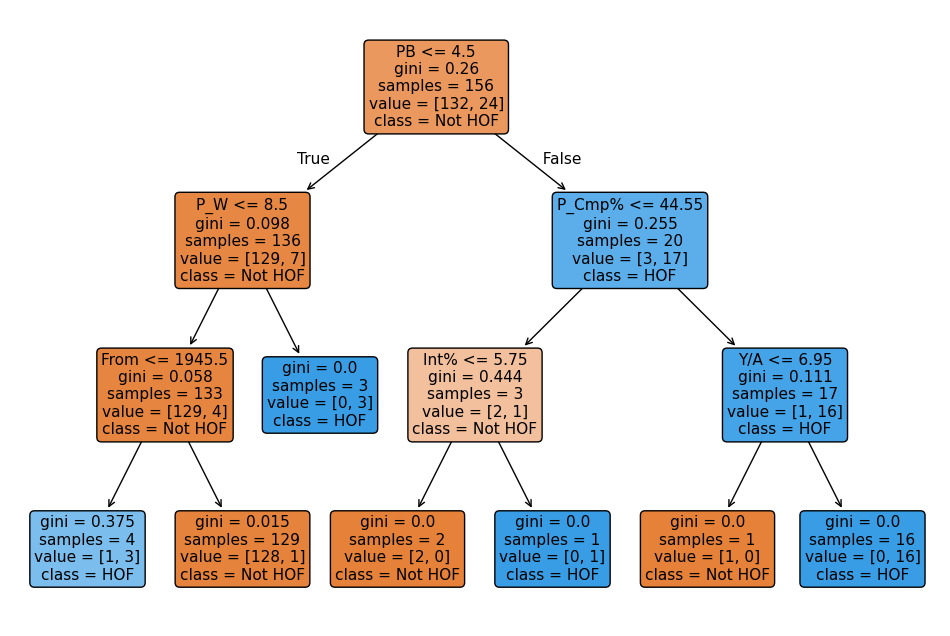

In [36]:
models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Decision Tree-3': DecisionTreeClassifier(random_state=42, max_depth=3),
    'KNN' : KNeighborsClassifier(n_neighbors=3),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': accuracy})
    
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-"*40)

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Accuracy', ascending=False))

plt.figure(figsize=(12,8)) # Adjust figure size for better clarity
plot_tree(models['Decision Tree-3'], 
            feature_names=X.columns, # Show feature names on the tree
              class_names=['Not HOF', 'HOF'], # Show class names
          filled=True, # Color nodes based on majority class
          rounded=True) # Draw node boxes with rounded corners
plt.show()